# Visualizing Relationships Between Quantitative Features
## Lab 3.3 Submission by Haley Eason

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

sns.set(style="whitegrid")

In [2]:
df = pd.read_csv("Employee_productivity.csv")
df.head()

,HoursWorked,FocusScore,ProductivityScore,Department,YearsAtCompany,TeamMeetingsPerWeek,DeskLocation
0,42.4,6.3,3127.96,Engineering,17,0,Open Plan
1,34.0,7.2,4742.60,HR,8,6,Private Office
2,47.2,5.6,2044.73,Sales,15,3,Remote
3,38.4,9.0,5818.92,HR,5,6,Private Office
4,36.4,2.5,1841.31,Sales,9,6,Remote


## Productivity vs Years at Company

Text(0.5, 1.0, 'Productivity vs Years At Company')

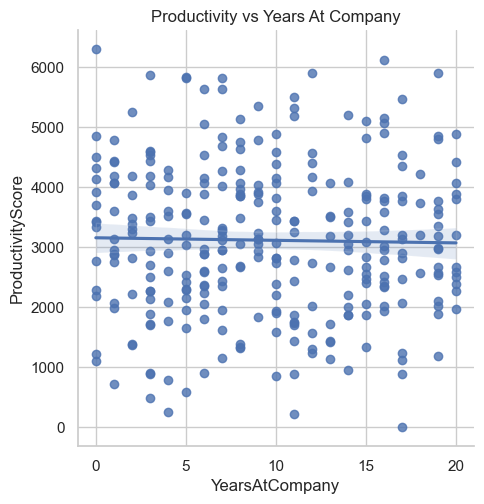

In [6]:
sns.lmplot(data=df, x="YearsAtCompany", y="ProductivityScore")
plt.title("Productivity vs Years At Company")

### Interpretation for "Productivity vs YearsAtCompany":
This visualization shows no meaningful relationship between years at the company and productivity. The points are widely scattered with no upward or downward trend, and the regression line is nearly flat.

In [8]:
X = sm.add_constant(df["YearsAtCompany"])
y = df["ProductivityScore"]

model_years = sm.OLS(y, X).fit()
model_years.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      ProductivityScore   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.003
Method:                 Least Squares   F-statistic:                    0.1227
Date:                Sat, 21 Mar 2026   Prob (F-statistic):              0.726
Time:                        14:22:39   Log-Likelihood:                -2564.1
No. Observations:                 300   AIC:                             5132.
Df Residuals:                     298   BIC:                             5140.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const           3154.6734    136.338     23.139      0.000    2886.366    3422.981
YearsAtCompany    -4.2493     12.132     -0.350      0.726     -28.124      19.625
==============================================================================
Omnibus:                        2.338   Durbin-Watson:                   1.945
Prob(Omnibus):                  0.311   Jarque-Bera (JB):                2.025
Skew:                           0.091   Prob(JB):                        0.363
Kurtosis:                       2.641   Cond. No.                         21.3
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [9]:
model_years.rsquared

np.float64(0.00041152919389664255)

### Regression interpretation:
The simple linear regression confirms that R² ≈ 0.0004, meaning tenure explains less than 0.1% of the variation in productivity. The slope is very close to zero and not statistically significant (p = 0.726).

### Conslusion:
Years at the company does not predict productivity in this dataset.

## Productivity vs HoursWorked

Text(0.5, 1.0, 'Productivity vs Hours Worked')

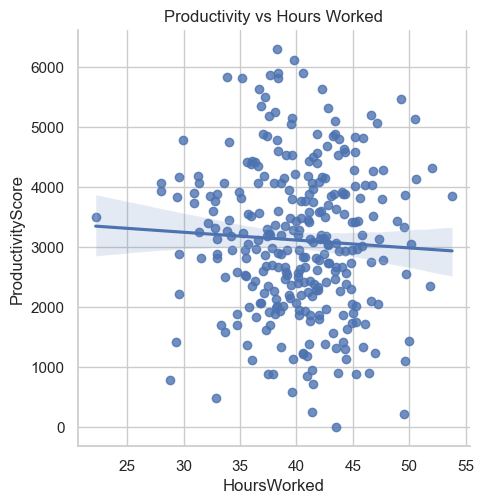

In [7]:
sns.lmplot(data=df, x="HoursWorked", y="ProductivityScore")
plt.title("Productivity vs Hours Worked")

### Interpretation for "Productivity vs HoursWorked":
This visualization shows a very weak and slightly negative relationship between hours worked and productivity. The points are widely scattered with no clear trend, and the regression line slopes gently downward, suggesting that working more hours does not reliably increase productivity.

In [10]:
X = sm.add_constant(df["HoursWorked"])
y = df["ProductivityScore"]

model_hours = sm.OLS(y, X).fit()
model_hours.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      ProductivityScore   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                    0.7768
Date:                Sat, 21 Mar 2026   Prob (F-statistic):              0.379
Time:                        14:24:28   Log-Likelihood:                -2563.7
No. Observations:                 300   AIC:                             5131.
Df Residuals:                     298   BIC:                             5139.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const        3638.4153    599.175      6.072      0.000    2459.265    4817.566
HoursWorked   -13.0329     14.787     -0.881      0.379     -42.133      16.068
==============================================================================
Omnibus:                        2.775   Durbin-Watson:                   1.953
Prob(Omnibus):                  0.250   Jarque-Bera (JB):                2.335
Skew:                           0.104   Prob(JB):                        0.311
Kurtosis:                       2.621   Cond. No.                         337.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [11]:
model_hours.rsquared

np.float64(0.0025999350022652967)

### Regression interpretation:
The simple linear regression confirms that R² ≈ 0.0026, meaning hours worked explain less than 1% of the variation in productivity. The slope is negative but not statistically significant (p = 0.379).

### Conslusion:
Hours worked do not meaningfully predict productivity in this dataset, and working longer hours may even be slightly counterproductive.


## Productivity vs FocusScore

Text(0.5, 1.0, 'Productivity vs Focus Score')

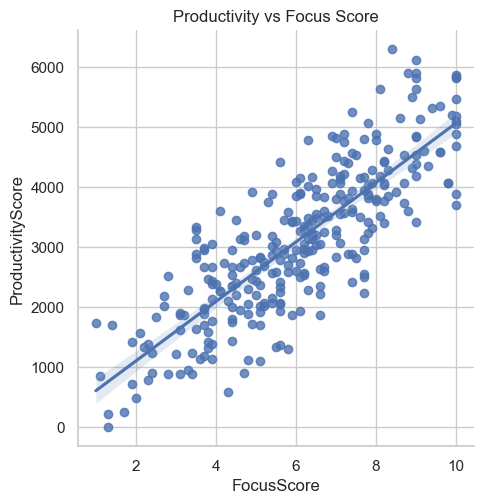

In [12]:
sns.lmplot(data=df, x="FocusScore", y="ProductivityScore")
plt.title("Productivity vs Focus Score")

### Interpretation for "Productivity vs FocusScore":
This visualization shows a strong positive linear relationship between focus and productivity. As FocusScore increases, ProductivityScore rises sharply and cocnsistently, with the regression line cutting cleanly throught the center of the data cloud. This is the only predictor that shows a clear, visually obvious trend.

In [13]:
X = sm.add_constant(df["FocusScore"])
y = df["ProductivityScore"]

model_focus = sm.OLS(y, X).fit()
model_focus.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      ProductivityScore   R-squared:                       0.678
Model:                            OLS   Adj. R-squared:                  0.677
Method:                 Least Squares   F-statistic:                     626.6
Date:                Sat, 21 Mar 2026   Prob (F-statistic):           3.02e-75
Time:                        14:28:38   Log-Likelihood:                -2394.3
No. Observations:                 300   AIC:                             4793.
Df Residuals:                     298   BIC:                             4800.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        114.3813    126.657      0.903      0.367    -134.874     363.636
FocusScore   494.9319     19.772     25.032      0.000     456.021     533.843
==============================================================================
Omnibus:                        0.756   Durbin-Watson:                   2.057
Prob(Omnibus):                  0.685   Jarque-Bera (JB):                0.869
Skew:                           0.076   Prob(JB):                        0.648
Kurtosis:                       2.784   Cond. No.                         20.2
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [14]:
model_focus.rsquared

np.float64(0.6776960770307456)

### Regression interpretation:
The simple linear regression confirms the visual pattern of R² ≈ 0.678, meaning FocusScore alone explains about 68% of the variation on productivity--an extremely strong relationship for real-word data. The slope is large and highly significant (p < 0.001), indicating that increases in focus are strongly associated with higher productivity.

### Concusion:
FocusScore is by far the strongest single predictor of productivity in the dataset, dwarfing the effects of years at the company and hours worked.

### Compare the Three R² Values

In [15]:
print("R² (YearsAtCompany):", model_years.rsquared)
print("R² (HoursWorked):", model_hours.rsquared)
print("R² (FocusScore):", model_focus.rsquared)

R² (YearsAtCompany): 0.00041152919389664255
R² (HoursWorked): 0.0025999350022652967
R² (FocusScore): 0.6776960770307456


FocusScore has the strongest linear relationship with ProductivityScore (R² ≈ 0.68), while YearsAtCompany and HoursWorked show almost no linear relationship (R² < 0.01).

### Multiple Regression Model: Evaluating All Features

In [22]:
X = df[[
    "YearsAtCompany",
    "HoursWorked",
    "FocusScore",
    "TeamMeetingsPerWeek",
    "DeskLocation",
    "Department"
]]

X = pd.get_dummies(X, drop_first=True)
X = sm.add_constant(X)

# 🔧 FIX: convert all columns (including bools) to numeric floats
X = X.astype(float)

y = df["ProductivityScore"]

model_full = sm.OLS(y, X).fit()
model_full.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      ProductivityScore   R-squared:                       0.685
Model:                            OLS   Adj. R-squared:                  0.675
Method:                 Least Squares   F-statistic:                     70.11
Date:                Sat, 21 Mar 2026   Prob (F-statistic):           1.53e-67
Time:                        14:45:30   Log-Likelihood:                -2390.8
No. Observations:                 300   AIC:                             4802.
Df Residuals:                     290   BIC:                             4839.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
===============================================================================================
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const                         255.7046    399.258      0.640      0.522    -530.105    1041.515
YearsAtCompany                  3.4008      6.992      0.486      0.627     -10.360      17.162
HoursWorked                    -4.6642      8.541     -0.546      0.585     -21.474      12.146
FocusScore                    512.7193     21.748     23.575      0.000     469.915     555.523
TeamMeetingsPerWeek            27.1706     24.914      1.091      0.276     -21.864      76.206
DeskLocation_Private Office  -103.4120    100.491     -1.029      0.304    -301.197      94.373
DeskLocation_Remote          -229.7530    106.847     -2.150      0.032    -440.047     -19.459
Department_HR                 -93.3984    115.183     -0.811      0.418    -320.100     133.303
Department_Marketing         -136.2405    118.380     -1.151      0.251    -369.234      96.753
Department_Sales              -49.8174    117.871     -0.423      0.673    -281.809     182.174
==============================================================================
Omnibus:                        0.168   Durbin-Watson:                   2.043
Prob(Omnibus):                  0.920   Jarque-Bera (JB):                0.295
Skew:                           0.024   Prob(JB):                        0.863
Kurtosis:                       2.854   Cond. No.                         412.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Final Summary and Reccomendations:
Across the three simple linear regression models, FocusScore showed the strongest linear relationship with productivity, with an R² of approximately 0.68. In contrast, YearsAtCompany and HoursWorked had R² values near to zero, indicating almost no predictive power. These results were also visually supported by the scatterplots: focus displayed a clear upward trend, while the other two variables showed no meaningful pattern.

Building on this, the multiple regression model explained about 68% of the variance in productivity (Adjusted R² = 0.675). Within this model, FocusScore remained by far the most significant predictor, while YearsAtCompany, HoursWorked, TeamMeetingPerWeek, and most department and desk location variables were not statistically significant. The only additional significant factor was DeskLocation_Remote, suggesting that remote employees had slightly lower productivity compared to in-office employees.

Overall, the data shows that focus is the primary driver of productivity at this company. Based on these findings, the company should prioritize strategies that help employees maintain or improve focus--such as reducing distractions, improving workspace conditions, and supporting deep-work time. Additionally, remote workers may benefit from clearer structure, better communication tools, or improved home-office setups to help close the productivity gap.